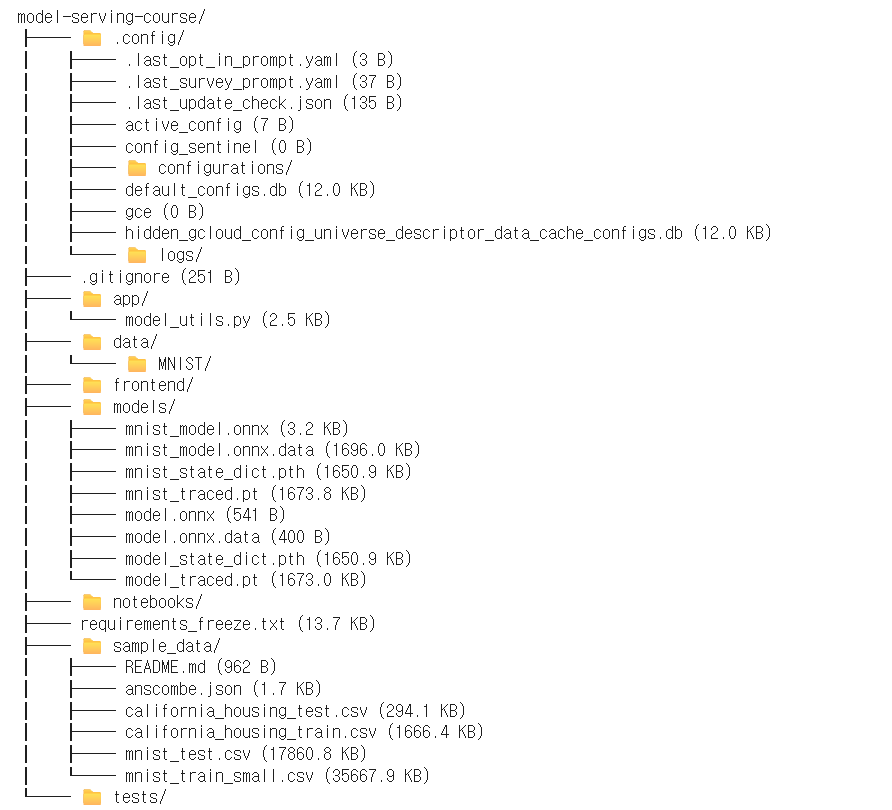

### ✅ 체크포인트 1


1. `.pth` 파일만 전달했을 때, 상대방이 모델을 바로 사용할 수 없는 이유는 무엇입니까?
- **'.pth'파일은 가중치만 저장하기 때문에 클래스 정의가 별도로 필요**
2. 모델 학습(Training)과 모델 배포(Serving)의 핵심 차이를 한 문장으로 설명할 수 있습니까?
- **학습이 "좋은 모델을 만드는 것"이라면, 배포는 "그 모델을 세상에 꺼내놓는 것" 입니다.**
3. 모델 배포에서 사용자와 서버가 소통하는 방식은 무엇입니까?
- **HTTP(API)를 통해 소통함**



### ✅ 체크포인트 2

1.  **가상환경 없이 `pip install`을 하면 패키지가 어디에 설치됩니까? 그것이 왜 문제가 될 수 있습니까?**
    *   가상환경 없이 `pip install`을 하면 패키지는 시스템의 전역 Python 환경(Global Python Environment)에 설치됩니다. 일반적으로 `/usr/local/lib/pythonX.Y/site-packages`와 같은 경로에 설치됩니다.
    *   **문제점:**
        *   **종속성 충돌:** 여러 프로젝트가 각각 다른 버전의 동일한 패키지를 필요로 할 경우, 전역 환경에서는 버전 충돌이 발생하여 한 프로젝트가 제대로 작동하지 않거나 모든 프로젝트가 오작동할 수 있습니다.
        *   **환경 오염:** 불필요한 패키지들이 전역 환경에 계속 쌓여 시스템 Python 환경을 복잡하게 만들고, 나중에 어떤 패키지가 어떤 프로젝트에 사용되는지 파악하기 어렵게 만듭니다.
        *   **재현성 저하:** 특정 프로젝트가 어떤 패키지 버전을 필요로 하는지 정확히 알기 어렵고, 다른 개발자나 배포 환경에서 동일한 환경을 정확히 재현하기 어려워집니다.

2.  **`pip freeze`로 생성한 파일과 직접 작성한 `requirements.txt`의 차이는 무엇입니까?**
    *   **`pip freeze`로 생성한 파일:** 현재 활성화된 Python 환경에 설치된 모든 패키지와 그 정확한 버전(예: `package==1.2.3`)을 나열합니다. 이는 특정 시점의 환경을 '스냅샷'처럼 기록하여 환경을 정확히 재현하는 데 유용합니다.
    *   **직접 작성한 `requirements.txt`:** 프로젝트가 작동하는 데 **필수적인 최소한의 패키지**만 명시적으로 작성합니다. 버전은 `package>=1.0`, `package~=1.2`와 같이 유연하게 지정하거나, `package`처럼 특정 버전 없이 작성하기도 합니다. 이는 종속성 그래프를 관리하고 불필요한 패키지 설치를 줄이는 데 목적이 있습니다.
    *   **주요 차이:** `pip freeze`는 모든 종속성까지 포함한 **전체 환경**을, 직접 작성한 `requirements.txt`는 프로젝트의 **핵심 종속성**을 관리하는 데 사용됩니다.

3.  **동료에게 프로젝트를 전달할 때, `.venv` 폴더 대신 무엇을 공유해야 합니까?**
    *   동료에게 프로젝트를 전달할 때는 `.venv` 폴더 대신 **`requirements.txt` 파일**을 공유해야 합니다. `.venv` 폴더는 용량이 크고 운영체제 및 환경에 따라 재현이 어려울 수 있습니다.
    *   `requirements.txt` 파일만 공유하면, 동료는 이 파일을 사용하여 자신의 환경에 프로젝트에 필요한 패키지들을 쉽게 설치하고 동일한 개발 환경을 구축할 수 있습니다.

### ✅ 체크포인트 3

1.  **모델 추론 요청에 GET이 아닌 POST를 사용하는 이유는 무엇입니까?**
    *   **GET 요청:** 주로 서버에서 데이터를 조회할 때 사용하며, 요청 본문(body)이 없습니다. 모든 데이터는 URL의 쿼리 파라미터로 전송됩니다. 민감한 데이터나 길이가 긴 데이터를 URL에 노출하는 것은 보안상, 기능상 적절하지 않습니다.
    *   **POST 요청:** 서버에 데이터를 생성하거나 업데이트할 때 사용하며, 요청 본문에 데이터를 담아 보낼 수 있습니다. 모델 추론은 입력 데이터를 본문에 담아 서버로 보내야 하고, 이 데이터는 민감할 수 있으며 길이가 길 수 있습니다. 따라서 안전하고 효율적으로 데이터를 전송하기 위해 POST 요청을 사용합니다.

2.  **상태 코드 `422`는 어떤 상황에서 발생합니까?**
    *   HTTP 상태 코드 `422 Unprocessable Entity`는 서버가 요청을 이해했지만, 요청 본문(payload)에 포함된 데이터의 유효성 검사에 실패하여 요청을 처리할 수 없을 때 발생합니다. 즉, 요청의 문법은 올바르지만(예: JSON 형식은 맞음), 서버의 비즈니스 로직이나 데이터 유효성 규칙(예: 필수 필드 누락, 데이터 형식 오류, 값의 범위 벗어남 등)을 충족하지 못할 때 사용됩니다. FastAPI에서 Pydantic 모델을 통해 요청을 받을 때, 정의된 모델 스키마에 맞지 않는 데이터가 들어오면 자동으로 `422` 상태 코드를 반환합니다.

3.  **`requests.post(url, json=data)`에서 `json=` 파라미터는 내부적으로 어떤 일을 합니까?**
    *   `requests.post(url, json=data)`에서 `json=data` 파라미터는 `requests` 라이브러리가 다음 두 가지 작업을 자동으로 수행하도록 지시합니다:
        1.  **Python 딕셔너리(`data`)를 JSON 문자열로 직렬화(Serialization):** `data` 객체를 `json.dumps(data)`와 같이 JSON 문자열로 변환합니다.
        2.  **`Content-Type` 헤더 설정:** 요청 헤더에 `Content-Type: application/json`을 자동으로 추가합니다. 이 헤더는 서버에게 요청 본문의 데이터가 JSON 형식임을 알려줍니다.

4.  **Python의 `True`는 JSON에서 어떻게 표현됩니까?**
    *   Python의 `True`는 JSON에서 **`true`** (소문자)로 표현됩니다. JSON 표준은 부울(Boolean) 값을 소문자 `true` 또는 `false`로 정의합니다.

### ✅ 체크포인트 4

1.  **`state_dict`로 저장한 `.pth` 파일을 불러올 때, 모델 클래스 정의가 필요한 이유는 무엇입니까?**
    *   `state_dict`는 모델의 **학습된 파라미터(가중치와 편향 등)만을 저장**합니다. 모델의 **구조(어떤 레이어들로 구성되어 있고 어떻게 연결되었는지)** 에 대한 정보는 포함하지 않습니다. 따라서 `state_dict`를 불러와 적용하려면, 파라미터를 로드할 대상이 되는 모델 클래스 정의가 미리 준비되어 있어야 합니다.

2.  **`torch.jit.trace`와 `torch.jit.script`는 각각 어떤 상황에서 사용합니까?**
    *   `torch.jit.trace`: 모델의 **연산 그래프가 고정적이고 입력에 따라 제어 흐름이 변하지 않을 때** 사용합니다. 모델에 `if/else` 분기나 `for` 루프와 같은 동적인 제어 흐름이 없을 때 적합하며, 더 안정적으로 변환됩니다.
    *   `torch.jit.script`: 모델에 `if/else` 분기, `for` 루프 등 **동적인 제어 흐름이 포함되어 있을 때** 사용합니다. Python 코드를 직접 분석하여 TorchScript로 컴파일하므로, 동적인 로직도 변환할 수 있습니다.

3.  **ONNX의 가장 큰 장점은 무엇이며, 어떤 상황에서 선택해야 합니까?**
    *   ONNX의 가장 큰 장점은 **프레임워크 독립성(Framework Agnostic)** 입니다. PyTorch로 학습한 모델을 TensorFlow, MXNet 등 다른 딥러닝 프레임워크 환경에서 실행해야 하거나, NVIDIA TensorRT, OpenVINO 등 특정 하드웨어에 최적화된 추론 엔진을 활용하여 **최고의 추론 성능을 달성해야 할 때** ONNX를 선택합니다.

4.  **`torch.onnx.export()`에서 `dynamic_axes`를 지정하지 않으면 어떤 문제가 생길 수 있습니까?**
    *   `dynamic_axes`를 지정하지 않으면 ONNX 모델은 **특정 입력 차원(예: 배치 크기, 이미지 높이/너비)이 고정된 것으로 간주**됩니다. 이 경우, 모델을 불러와 추론할 때 `export` 시 사용했던 것과 다른 크기의 입력을 사용하면 `RuntimeError`가 발생하거나 모델이 올바르게 동작하지 않을 수 있습니다. `dynamic_axes`를 지정하여 **가변적인 입력 크기에 대응**할 수 있게 됩니다.